  <div class="alert alert-info">
  Привет, Алина! Меня зовут Светлана Чих и я буду проверять твой проект. Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе. Предлагаю общаться на «ты». Но если это не удобно - дай знать, и мы перейдем на «вы».

  <div class="alert alert-success">
  <b>👍 Успех:</b> Зелёным цветом отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах.
  </div>
  <div class="alert alert-warning">
  <b>🤔 Рекомендация:</b> Жёлтым цветом выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).
  </div>
  <div class="alert alert-danger">
  <b>😔 Необходимо исправить:</b> Красным цветом выделены комментарии, без исправления которых, я не смогу принять проект :(
  </div>
  <div class="alert alert-info">
  <b>👂 Совет:</b> Какие-то дополнительные материалы
  </div>
  Давай работать над проектом в диалоге: если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом.
  Мне будет легче отследить изменения, если ты выделишь свои комментарии:
  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Например, вот так.</div>
  Пожалуйста, не перемещай, не изменяй и не удаляй мои комментарии. Всё это поможет выполнить повторную проверку твоего проекта быстрее.
   </div>

# Описание проекта 

В рамках проекта по машинному обучению мне предстоить помочь фермеру тщательно отобрать коров для покупки в ассоциации пастбиц "Экоферма", чтобы они удовлетворяли следующим критериям:
- средний удой за год — не менее 6000 килограммов;
- молоко должно быть вкусным.

Для этого в своей работе я проделаю следующие шаги:

**Шаг 1** Загрузка и изучение данных.

**Шаг 2** Предобработка данных: 
- проверить данные на наличие дубликатов и пропусков, при необходимости обработать их;
- проверить корректность типов данных для каждого столбца.

**Шаг 3** Исследовательский анализ данных:
- провести статистический анализ всех признаков;
- построить графики для каждого признака;
- сделит выводы о данных: имеются ли в данных выбросы, необычное распределение количественных признаков или другие особенности;
- описать стратегию улучшения данных.

**Шаг 4** Корреляционный анализ данных в датасете ferma_main.csv:
- рассчитать коэффициент корреляции между всеми признаками;
- построить диаграммы рассеяния scatterplot для признака Удой и всех количественных признаков;
- сделать вывод о взаимосвязи признаков.

**Шаг 5** Обучение модели линейной регрессии:
- обучить 3 модели линейной регрессии для определения целевого признака Удой;
- посчитать метрики качества для этих трех моделей (MAE, R2, MSE и др);
- исходя из метрик выбрать наиболее качественную модель и спрогнозировать удой для коров, которых хочет купить фермер.

**Шаг 6** Обучение модели логистической регрессии:
- обучить логистическую модель для задачи классификации молока по целевому признаку Вкус;
- проанализировать модель, определить какая ошибка критичнее для задачи (ошибка первого или второго рода), исходя из этого скорректировать модель;
- с помощью модели спрогнозировать вкус молока для коров, которых хочет купить фермер.

**Шаг 7** Сделать итоговые выводы:
- добавить прогнозы вкуса молока и удоя коров "Экофермы" в датафрейм с коровами, покупку которых рассматривает фермер;
- отобрать коров, которые подходят под критерии фермера;
- описать результаты работы моделей для фермера;
- посчитать количество коров, которое может купить фермер с минимальным риском;
- сделать выводы о качестве и улучшении моделей.

## Шаг 1 Загрузка данных

In [1]:
# импортируем все необходимые библиотеки и модули
import pandas as pd
import numpy as np
from scipy.stats import percentileofscore
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import confusion_matrix

In [2]:
# прочитаем файлы 
ferma_main = pd.read_csv('/datasets/ferma_main.csv')

Изучим первые 5 строк таблицы ferma_main 

In [3]:
ferma_main.head()

,id;Удой,кг;ЭКЕ (Энергетическая кормовая единица);Сырой протеин,г;СПО (Сахаро-протеиновое соотношение);Порода;Тип пастбища;порода папы_быка;Жирность,%;Белок,%;Вкус молока;Возраст
0,1;5863;14,2;1743;0,89;Вис Бик Айдиал;Равнинное;Айдиал;3,58;3,076;вкусно;более_2_лет
1,2;5529;12,8;2138;0,89;Вис Бик Айдиал;Равнинные;Соверин;3,54;3,079;вкусно;менее_2_лет
2,3;5810;14;1854;0,885;РефлешнСоверинг;Холмистое;Соверин;3,59;3,074;не вкусно;более_2_лет,NaN
3,4;5895;12,4;2012;0,885;РефлешнСоверинг;Холмистое;Айдиал;3,4;3,075;не вкусно;более_2_лет
4,5;5302;12,8;1675;0,885;Вис Бик Айдиал;Равнинные;Соверин;3,73;3,073;вкусно;менее_2_лет


Из таблицы видно, что данные разделены не запятой, а ";", поэтому нужно перечитать файлы с правильным разделителем

In [4]:
ferma_main = pd.read_csv('/datasets/ferma_main.csv', sep=';')
ferma_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
cow_buy = pd. read_csv('/datasets/cow_buy.csv', sep=';')

In [5]:
ferma_main.head() 

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [6]:
ferma_dad.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [7]:
cow_buy.head()

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


Необходимо переименовать столбцы согласно стандарту PEP8: названия на английском языке в snake_case

In [8]:
ferma_main.columns = [
     "id",
     "milk_yield_kg",
     "feed_energy_unit",          
     "crude_protein_g",
     "sugar_protein_ratio",       
     "breed",
     "pasture_type",
     "dad_breed",
     "fat_percent",
     "protein_percent",
     "milk_taste",
     "age"
   ]
# переименуем стобцы в датасете ferma_main

In [9]:
ferma_dad.columns = [
    "id",
    "dad_name"   
]
# переименуем стобцы в датасете ferma_dad

In [10]:
cow_buy.columns = [
    "breed",
    "pasture_type",
    "dad_breed",
    "dad_name",
    "current_fat_percent",
    "current_protein_percent",
    "age"
]
# переименуем стобцы в датасете cow_buy

In [11]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   634 non-null    int64 
 1   milk_yield_kg        634 non-null    int64 
 2   feed_energy_unit     634 non-null    object
 3   crude_protein_g      634 non-null    int64 
 4   sugar_protein_ratio  634 non-null    object
 5   breed                634 non-null    object
 6   pasture_type         634 non-null    object
 7   dad_breed            634 non-null    object
 8   fat_percent          634 non-null    object
 9   protein_percent      634 non-null    object
 10  milk_taste           634 non-null    object
 11  age                  634 non-null    object
dtypes: int64(3), object(9)
memory usage: 59.6+ KB


In [12]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   dad_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [13]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   breed                    20 non-null     object
 1   pasture_type             20 non-null     object
 2   dad_breed                20 non-null     object
 3   dad_name                 20 non-null     object
 4   current_fat_percent      20 non-null     object
 5   current_protein_percent  20 non-null     object
 6   age                      20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


**Вывод:** В ходе изучения данных я изменила названия столбцов датафреймов столбцы на английском языке и в стиле snake_case. При изучении общей информации о данных видно, что датафреймы не имеют пропусков, однако в таблице ferma_dad на 5 значений меньше, чем в таблице ferma_main, это значит, что не для всех коров фермера известно имя отца. 

<div class="alert alert-success">
<b>👍 Успех:</b> Импортированы нужные библиотеки, данные загружены и просмотрены!
</div>

##  Шаг 2 Предобработка данных

### Предобработка данных в датафрейме ferma_main

In [14]:
ferma_main.duplicated().sum()
# проверим таблицу ferma_main на наличие полных дубликатов

5

In [15]:
ferma_main = ferma_main.drop_duplicates().reset_index(drop=True)
# удалим полные дубликаты в таблице ferma_main

In [16]:
ferma_main['breed'].unique()
# проверим неявные дубликаты в колонке 'breed' 

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [17]:
ferma_main['pasture_type'].unique()
# проверим неявные дубликаты в колонке 'pasture_type' 

array(['Равнинное', 'Равнинные', 'Холмистое'], dtype=object)

In [18]:
ferma_main['dad_breed'].unique()
# проверим неявные дубликаты в колонке 'dad_breed' 

array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

В колонках 'pasture_type' и 'dad_breed' имеются неявные дубликаты, устраним их

In [19]:
ferma_main['pasture_type'] = (
    ferma_main['pasture_type']
    .replace('Равнинные', 'Равнинное')
)   
# устраним неявные дубликаты в колонке 'pasture_type'

In [20]:
ferma_main['dad_breed'] = (
    ferma_main['dad_breed']
    .replace('Айдиалл', 'Айдиал')
)
# устраним неявные дубликаты в колонке 'dad_breed'

In [21]:
ferma_main.dtypes
# изучим типы данных в датафрейме ferma_main

id                      int64
milk_yield_kg           int64
feed_energy_unit       object
crude_protein_g         int64
sugar_protein_ratio    object
breed                  object
pasture_type           object
dad_breed              object
fat_percent            object
protein_percent        object
milk_taste             object
age                    object
dtype: object

Поменяем типы данных в колонках 'feed_energy_unit', 'sugar_protein_ratio', 'fat_percent', 'protein_percent' на числовой.

In [22]:
cols = ['feed_energy_unit', 'sugar_protein_ratio', 'fat_percent', 'protein_percent']
for col in cols:
    ferma_main[col] = ferma_main[col].replace(',', '.', regex=True).apply(lambda x: pd.to_numeric(x))

# заменяем типы данных в колонках 

In [23]:
ferma_main.info()
# проверим информацию об обработанных данных в таблице ferma_main

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   629 non-null    int64  
 1   milk_yield_kg        629 non-null    int64  
 2   feed_energy_unit     629 non-null    float64
 3   crude_protein_g      629 non-null    int64  
 4   sugar_protein_ratio  629 non-null    float64
 5   breed                629 non-null    object 
 6   pasture_type         629 non-null    object 
 7   dad_breed            629 non-null    object 
 8   fat_percent          629 non-null    float64
 9   protein_percent      629 non-null    float64
 10  milk_taste           629 non-null    object 
 11  age                  629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 59.1+ KB


<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Предобработка данных в датафрейме ferma_dad

In [24]:
ferma_dad.duplicated().sum()
# проверим датафрейм на наличие полных дубликатов

0

In [25]:
ferma_dad['dad_name'].unique()
# проверим датафрем на наличие неявных дубликатов

array(['Буйный', 'Соловчик', 'Барин', 'Геркулес'], dtype=object)

In [26]:
ferma_dad.dtypes
# проверим типы данных в датафрейме

id           int64
dad_name    object
dtype: object

Данные в таблице 'ferma_dad' не имеют проблем

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Предобработка данных в датафрейме cow_buy

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Нельзя удалять строки не посмотрев на них, почему было принято решение, что это дубликаты? В датасете есть признаки, однозначно характеризующие корову? Фермеру предложили к покупке 20 коров, он ждет прогноз по всем 20, а не частично</s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Да, действительно, не учла тот факт, что разные коровы могут иметь одинаковые характеристики.</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Дубликаты важно удалять только в обучающей выборке.
</div>

In [27]:
cow_buy['breed'].unique()
# проверяем наличие неявных дубликатов в колонке 'breed'

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [28]:
cow_buy['pasture_type'].unique()
# проверяем наличие неявных дубликатов в колонке 'pasture_type'

array(['холмистое', 'равнинное'], dtype=object)

In [29]:
cow_buy['dad_breed'].unique()
# проверяем наличие неявных дубликатов в колонке 'dad_breed'

array(['Айдиал', 'Соверин'], dtype=object)

In [30]:
cow_buy['dad_name'].unique()
# проверяем наличие неявных дубликатов в колонке 'dad_name'

array(['Геркулес', 'Буйный', 'Барин', 'Соловчик'], dtype=object)

In [31]:
cow_buy.dtypes

breed                      object
pasture_type               object
dad_breed                  object
dad_name                   object
current_fat_percent        object
current_protein_percent    object
age                        object
dtype: object

Необходимо поменять тип данных в колонках 'current_fat_percant' и 'current_protein_percent'

In [32]:
cols = ['current_fat_percent', 'current_protein_percent']
for col in cols:
    cow_buy[col] = cow_buy[col].replace(',', '.', regex=True).apply(lambda x: pd.to_numeric(x))

In [33]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   breed                    20 non-null     object 
 1   pasture_type             20 non-null     object 
 2   dad_breed                20 non-null     object 
 3   dad_name                 20 non-null     object 
 4   current_fat_percent      20 non-null     float64
 5   current_protein_percent  20 non-null     float64
 6   age                      20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


### Вывод

Из первого шага мы выяснили, что в датасетах нет пропусков. 

В ходе предобработки данных были удалены полные дубликаты в датасетах 'ferma_main' и 'cow_buy', удалены неявные дубликаты в колонках 'dad_breed' и 'pasture_type' в датафрейме 'ferma_main', изменены типы данных в некоторых колонках датафреймов 'ferma_main' и 'cow_buy' на числовые. 
В датафрейме 'ferma_dad' дубликатов, неявных дубликатов и проблем с типами данных не было обнаружено.
После предобработки данных количество строк в датафреймах 'ferma_main' и 'ferma_dad' сравнялось, а значит, для каждой коровы из датафрейма 'ferma_main' можно узнать имя отца из датафрейма 'ferma_dad'

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! (кроме удаления данных)
</div>

## Шаг 3 Исследовательский анализ данных

### Создание функций для анализа

In [34]:
translation_dict = {
    'milk_yield_kg' : 'удой',
    'feed_energy_unit': 'энергетическая кормовая единица',
    'crude_protein_g': 'сырой протеин',
    'sugar_protein_ratio': 'сахаро-протеиновое отношение',
    'breed': 'порода',
    'pasture_type': 'тип пастбища',
    'dad_breed': 'порода отца',
    'fat_percent': 'жирность молока',
    'protein_percent': 'количества белка',
    'milk_taste': 'вкус молока',
    'age': 'возраст' 
}
# создадим словарь с переводом колонок на русский язык

In [35]:
def analyze_numeric_distribution(column):
    ferma_main[column].hist(bins=15, color='#F5C6AA')
    plt.xlabel(f'{translation_dict[column]}'.capitalize())
    plt.ylabel('Количество коров')
    plt.title(f'Распределение колонки "{translation_dict[column]}"')
    plt.show()
    return ferma_main[column].describe()
# создаем функцию для анализа количественных признаков и построения гистограммы

In [36]:
def analyze_categorical_distribution(column):
    counts = ferma_main[column].value_counts()
    counts.plot(kind='bar', color='#F5C6AA')
    plt.xlabel(f'{translation_dict[column]}'.capitalize())
    plt.ylabel('Количество коров')
    plt.title(f'Распределение колонки "{translation_dict[column]}"')
    plt.show()
    plt.pie(
    counts,
    labels=counts.index,
    autopct='%.1f%%')
    plt.title(f'Процентное соотношение колонки "{translation_dict[column]}"')
    plt.show()
    

### Исследовательский анализ

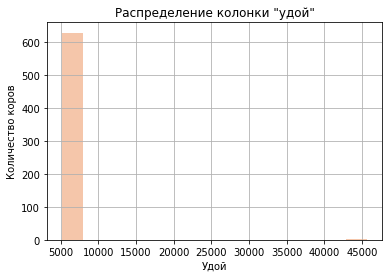

count      629.000000
mean      6188.750397
std       1644.795489
min       5204.000000
25%       5751.000000
50%       6133.000000
75%       6501.000000
max      45616.000000
Name: milk_yield_kg, dtype: float64

In [37]:
analyze_numeric_distribution('milk_yield_kg')
# проанализируем колонку 'milk_yield_kg'

По графику и описанию метода describe видно, что в данных есть определенно выбросы. 

Посчитаем межквартильный размах и значения правой и левой границы для исключения выбросов.

In [38]:
iqr = ferma_main['milk_yield_kg'].describe()['75%'] - ferma_main['milk_yield_kg'].describe()['25%'] 
# считаем межквартильный размах
left_border = ferma_main['milk_yield_kg'].describe()['25%'] - 1.5 * iqr
# считаем левую границу 
right_border = ferma_main['milk_yield_kg'].describe()['75%'] + 1.5 * iqr
# считаем правую границу 

In [39]:
left_border, right_border
# посмотрим на значения границ

(4626.0, 7626.0)

In [40]:
ferma_main.query('@left_border <= milk_yield_kg <= @right_border')['milk_yield_kg'].count()
# посчитаем количество данных без выбросов

628

Получается, что в данных всего один выброс - 45616. Учитывая, что это значение в несколько раз больше правой границы данных, можно определенно точно сказать, что этот выброс является случайным и корова не может дать такое количества молока. Выброс необходимо удалить. Однако, чтобы не осталось лишних данных в таблице 'ferma_dad' из нее тоже удалим корову с этим id

In [41]:
ferma_main.query('milk_yield_kg >= @right_border')['id']
# найдем значение id коровы, удой которой является выбросом

16    17
Name: id, dtype: int64

In [42]:
ferma_dad = ferma_dad.query('id != 17')
# удалим строчку в таблице ferma_dad с id коровы, удой которой является выбросом

In [43]:
ferma_main = ferma_main.query('@left_border <= milk_yield_kg <= @right_border')
# удалим выброс из таблицы ferma_main

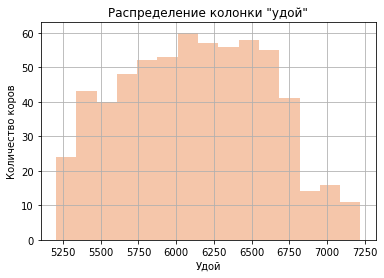

count     628.000000
mean     6125.968153
std       475.857053
min      5204.000000
25%      5749.750000
50%      6132.500000
75%      6501.000000
max      7222.000000
Name: milk_yield_kg, dtype: float64

In [44]:
analyze_numeric_distribution('milk_yield_kg')
# применим функцию без выбросов

In [45]:
percentileofscore(ferma_main['milk_yield_kg'], 6000, kind='mean')

41.0828025477707

Статистика по столбцу 'milk_yield_kg' (удой коровы) после удаления выброса стала более информативна и стабильна. Среднее значение (практически равное медиане) составляет 6125 кг в год. C помощью функции 'percentileofscore' я вычислила долю коров, удой которых меньше 6000 кг в год и она составила - 41%, 59% коров приносят больше 6000 кг в год. Неудивительно, что фермер не хочет брать коров с меньшим удоем, дабы сохранять среднее количество кг с каждой коровы и увеличивать его.

Данные по годовым удоям коров в хозяйствах распределены близко к нормальному закону, с единственной вершиной около 6 500 кг, присутствует легкая ассиметрия справа, но скошенность невелика.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Ни одна корова не дает столько молока!
</div>

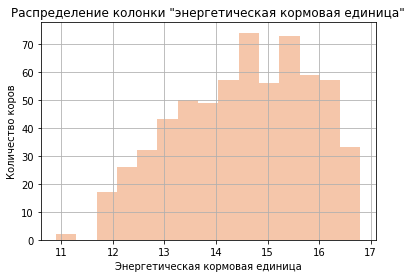

count    628.000000
mean      14.548726
std        1.301777
min       10.900000
25%       13.500000
50%       14.700000
75%       15.600000
max       16.800000
Name: feed_energy_unit, dtype: float64

In [46]:
analyze_numeric_distribution('feed_energy_unit')
# опишем информацию о данных в столбце 'feed_energy_unit'

В колонке 'feed_energy_unit' выбросов не наблюдается, среднее значение близко к значению медианы и равно 14.54 единиц. Распределение на гистограмме близко к нормальному, имеется лёгкая отрицательная асимметрия (более длинный левый хвост). Данные по столбцу 'feed_energy_unit' не имеют аномалий

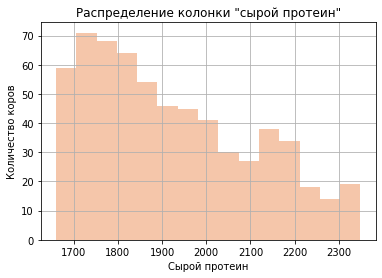

count     628.000000
mean     1923.759554
std       182.832816
min      1660.000000
25%      1771.750000
50%      1888.000000
75%      2062.250000
max      2349.000000
Name: crude_protein_g, dtype: float64

In [47]:
analyze_numeric_distribution('crude_protein_g')
# опишем информацию о данных в столбце 'crude_protein_g'

В колонке 'crude_protein_g' не наблюдается резких выбросов, которые выходили бы за рамки левой и правой границы. 
Распределение не похоже на нормальное, имеет скошенность справа, большая часть значения сосредоточена левее 2000 г, об этом можно судить и по 3-му квартилю. Cреднее значение больше медианы, что еще раз подтверждает скошенность данных вправо.

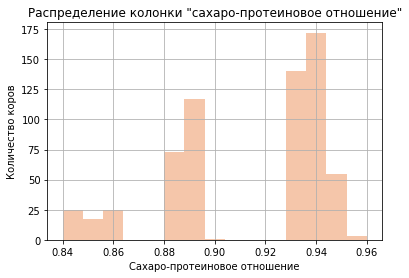

count    628.000000
mean       0.913089
std        0.032221
min        0.840000
25%        0.890000
50%        0.930000
75%        0.940000
max        0.960000
Name: sugar_protein_ratio, dtype: float64

In [48]:
analyze_numeric_distribution('sugar_protein_ratio')
# опишем колонку sugar_protein_ratio 

Среднее значение СПО меньше медианы, это говорит о том, что распределение имеет отрицательную асимметрию (более длинный хвост слева). На гистограмме видно бимодальное распределение: есть два пика в районе 0.88-0.90 и 0.92-0.96, между ними имеется "впадина" в которой практически нет значений. Это может говорить о том, что фермер использует 2 основных вида корма для своих коров

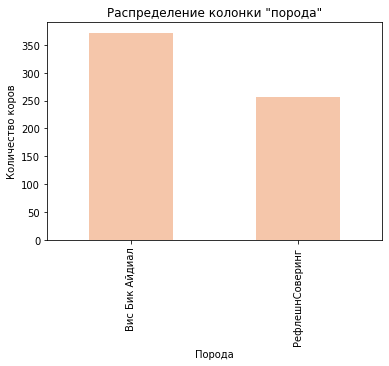

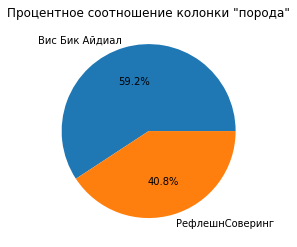

In [49]:
analyze_categorical_distribution('breed')
# построим столбачатую и круговую диаграммы для колонки 'breed'

На графике типа 'pie' видно, что 59.2% коров у фермера породы Вис Бик Айдиал, остальные 40.8% - породы РефлешнСоверинг.

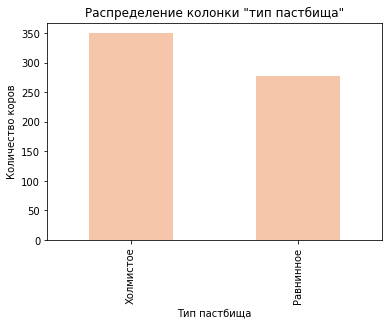

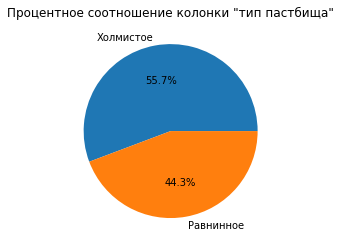

In [50]:
analyze_categorical_distribution('pasture_type')
# построим столбачатую и круговую диаграммы для колонки 'pasture_type'

На графике типа 'pie' видно, что 55.7% коров пасутся на холмистом пастбище, остальные 44.3% - на равнинном пастбище.

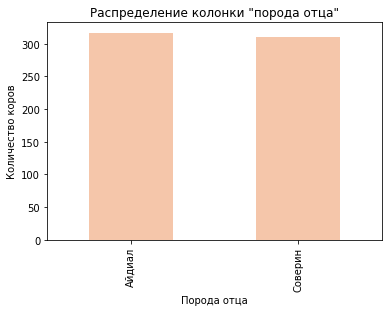

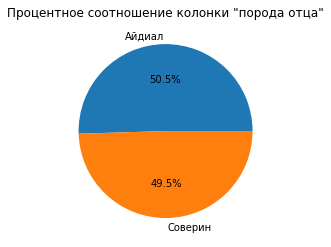

In [51]:
analyze_categorical_distribution('dad_breed')
# построим столбачатую и круговую диаграммы для колонки 'dad_breed'

На графике типа 'pie' видно, что у 50.5% коров порода отца - Айдиал, у остальных 49.5% - порода отца Соверин.

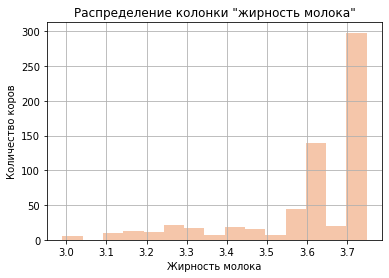

count    628.000000
mean       3.604268
std        0.168093
min        2.990000
25%        3.590000
50%        3.650000
75%        3.720000
max        3.750000
Name: fat_percent, dtype: float64

In [52]:
analyze_numeric_distribution('fat_percent')
# изучим значения в колонке 'fat_percent'

Есть подозрение, что в данных слева есть выброс, проверим это с помощью межквартильного размаха

In [53]:
iqr = ferma_main['fat_percent'].describe()['75%'] - ferma_main['fat_percent'].describe()['25%'] 
# считаем межквартильный размах
left_border = ferma_main['fat_percent'].describe()['25%'] - 1.5 * iqr
# считаем левую границу 
right_border = ferma_main['fat_percent'].describe()['75%'] + 1.5 * iqr
# считаем правую границу 

In [54]:
left_border, right_border
# посмотрим на значения границ

(3.3949999999999996, 3.915000000000001)

In [55]:
ferma_main.query('fat_percent <= @left_border')['id'].count()
# посчитаем количество коров, у которых процент жирности меньше левой границы

86

Таких коров получилось больше 10%, удалив эти данные можно не учесть довольно большую долю коров, поэтому в данном случае выбросы лучше оставить в данных.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Все данные реальны, хотя некоторые и довольно редкие, и жирность молоа величина не постоянная и зависит от состояния коровы и условий ее содержания
</div>

Медиана жирности молока больше среднего значения, на графике видна отрицательная ассиметрия (левосторонняя скошенность), большая часть значений лежит правее 3.59% это видно и на графике, и по 25-му перцентилю.

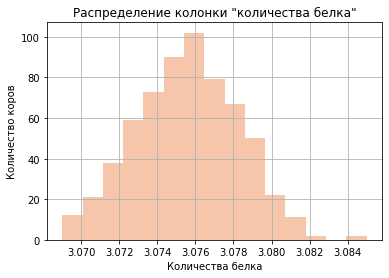

count    628.000000
mean       3.075670
std        0.002551
min        3.069000
25%        3.074000
50%        3.076000
75%        3.077000
max        3.085000
Name: protein_percent, dtype: float64

In [56]:
analyze_numeric_distribution('protein_percent')
# изучим значения в колонке 'protein_percent'

Распределение белка в молоке является нормальным, дисперсия значений невелика, это говорит о том, что все коровы дают молоко с примерном одинаковым процентом белка.

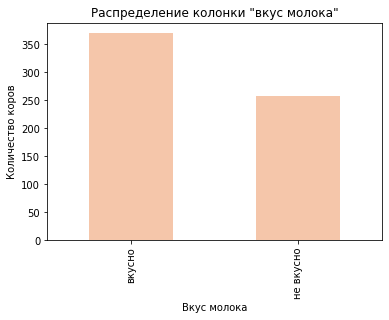

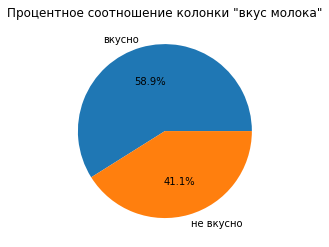

In [57]:
analyze_categorical_distribution('milk_taste')
# построим столбчатую и круговую диаграммы распределения по вкусу молока

В стаде фермера 58.9% коров имеют вкусное молоко, остальные 41.1% - невкусное. Доля невкусного молока достаточно велика, неудивительно, что фермер хочет обновить стадо.

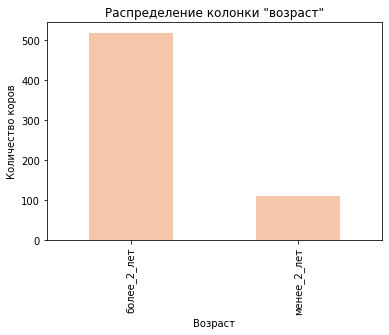

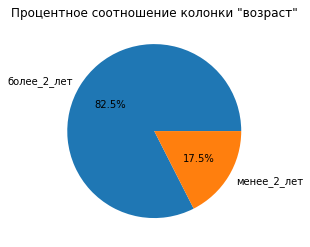

In [58]:
analyze_categorical_distribution('age')
# построим cтолбчатую и круговую диаграмму для колонки 'age'

Большая часть стада - 82.5% имеет возраст более 2 лет, остальные 17.5% - менее двух лет

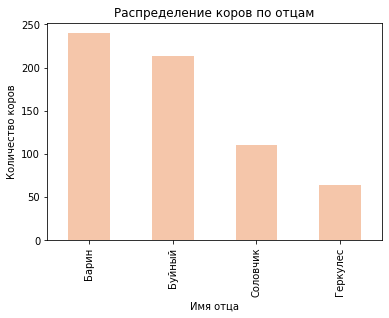

In [59]:
dad_counts = ferma_dad['dad_name'].value_counts()
dad_counts.plot(kind='bar', color='#F5C6AA')
plt.xlabel('Имя отца')
plt.ylabel('Количество коров')
plt.title('Распределение коров по отцам')
plt.show()
# изучим имена отцов по датасету 'ferma_dad' и распределение коров по ним

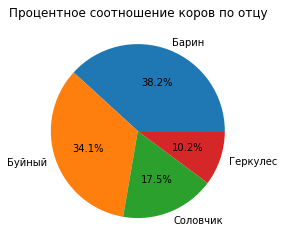

In [60]:
plt.pie(
    dad_counts,
    labels=dad_counts.index,
    autopct='%.1f%%')
plt.title('Процентное соотношение коров по отцу')
plt.show()
# построим круговую диаграмму для датасета 'ferma_dad'

Известно, что для всех коров есть только 4 отца-быка. Больше всего детей имеет бык по имени Барин (38.2%), меньше всего - бык Геркулес (10.2%)

### Вывод
В ходе исследовательского анализа данных я выяснила следующее:
 - в колонке milk_yield_kg был выброс, равный 45616 кг, который был благополучно удален из датасетов ferma_main и ferma_dad;
 - распределение удоя в год похоже на нормальное с небольшой положительной ассимметрией;
 - 41% коров имеют удой меньше 6000 кг в год;
 - энергетическая кормовая единица в среднем равняется 14.54, ее распределение похоже на нормальное, но слегка смещено вправо (75% всех коров получают корм с ЭКЕ вышло 13.5);
 - медианное содержание сырого протеина в корме составляет 1888 грамм, среднее значение больше медианы и равняется 1923 грамма, так как распределение имеет левостороннюю асимметрию, 75% коров получают корм, в котором меньше 2000 г протеина;
 - медианное значение сахарно-протеинового отношения в корме равняется 0.93, гистограмма имеет бимодальное распределение: есть два пика в районе 0.88-0.90 и 0.92-0.96, между ними имеется "впадина" в которой практически нет значений, возможно фермер использует 2 основных вида корма для коров;
 - 59.2% коров у фермера породы Вис Бик Айдиал, остальные 40.8% - породы РефлешнСоверинг;
 - 55.7% коров пасутся на холмистом пастбище, остальные 44.3% - на равнинном пастбище;
 - у 50.5% коров порода отца - Айдиал, у остальных 49.5% - порода отца Соверин;
 - распределение жирности молока имеет 86 выбросов слева, за счет чего оно сильно скошено, 75% коров дают молоко жирнее 3.6%, но в стаде есть коровы, жирность молока которых меньше 3%;
 - распределение процентного содержания белка в молоке нормальное, дисперсия мала, то есть все коровы дают примерно одинаковое по содержанию белка молоко (3.07%);
 - 58.9% коров имеют вкусное молоко, остальные 41.1% - невкусное;
 - большая часть стада - 82.5% имеет возраст более 2 лет, остальные 17.5% - менее двух лет;
 - для всех коров есть только 4 отца-быка: больше всего детей имеет бык по имени Барин (38.2%), меньше всего - бык Геркулес (10.2%).
 
 В данных практически не было выбросов (кроме колонки milk_yield_kg), многие признаки имеют скошенные распределения. Для дальнейшего использования данных их будет необходимо масштабировать, чтобы построить точную модель.
 
 Исходя из полученных результов видно, что 41% коров не соответствуют критериям фермера:
  - имеют удой меньше 6000 кг в год;
  - дают невкусное молоко.

Поэтому стремление фермера улучшить поголовье своего стада вполне оправдано и ожидаемо.


<div class="alert alert-success">
<b>👍 Успех:</b> Данные исследованы!
</div>

## Шаг 4 Корреляционный анализ

### Корреляционный анализ количественных данных

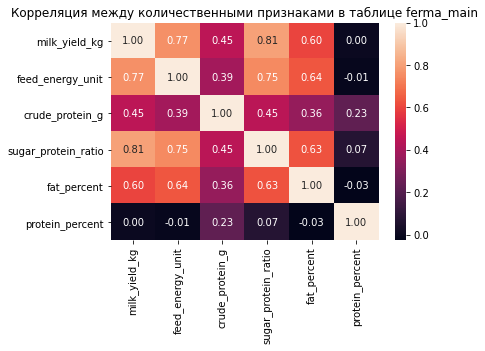

In [61]:
sns.heatmap(ferma_main.loc[:, 'milk_yield_kg':'protein_percent'].corr(), annot=True, fmt='.2f') 
plt.title('Корреляция между количественными признаками в таблице ferma_main')
plt.show()
# построим тепловую карту корреляции между количественными признаками в таблице ferma_main

Удой высоко коррелирует с ЭКЕ и СПО, заметно коррелирует с жирностью молока, с содержанием сырого протеина в корме корреляция умеренная, совсем не коррелирует с содержанием белка в молоке. Также можно заметить высокую корреляцию между ЭКЕ и СПО (0.75) это может создает проблему мультикоррелиарности, поэтому в дальнейшем для обучения модели будем использовать только один признак - СПО, так как он имеет большей коэффициент корреляции (0.81).

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Корреляционный анализ между удоем и количественными признаками с учетом качественных признаков

Создадим функцию для построения диаграммы рассеивания между количественным признаком (num_column) и удоем с учетом категориальных признаков (cat_column)

In [62]:
def scatter_plot(num_column, cat_column):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=num_column, y='milk_yield_kg', hue=cat_column, data=ferma_main, s=100)
    plt.title(
        f'Диаграмма рассеивания для признаков удой и {translation_dict[num_column]} ' 
        f'с учетом признака {translation_dict[cat_column]}'
        )
    plt.grid(True)
    plt.show()

Для того, чтобы отследить различие между корреляцией для разных типов категорий, создадим функцию correlation, которая на вход будет принимать количественный признак, зависимость от которого будем изучать на графике, и качественный признак

In [63]:
def correlation(num_column, cat_column):
    for category, group in ferma_main.groupby(cat_column):
        corr = group['milk_yield_kg'].corr(group[num_column])
        print(f'{translation_dict[cat_column].capitalize()}: {category}, '
              f'корреляция между признаками удой и {translation_dict[num_column]}: {corr:.2f}')

Исходя из матрицы корреляции выше для дальнейшего корреляционного анализа рассмотрим следующие количественные признаки: сырой протеин, сахаро-протеиновое отношение, жирность молока

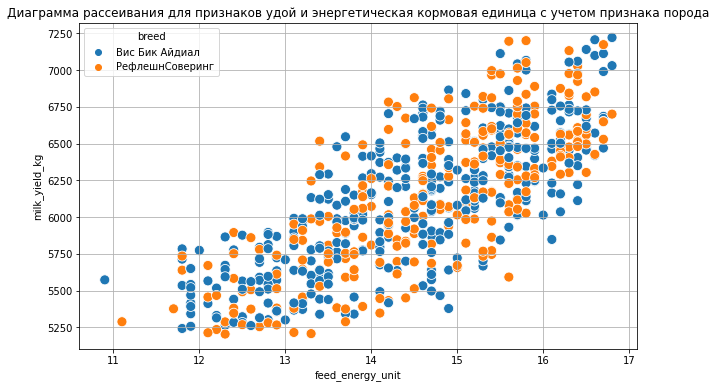

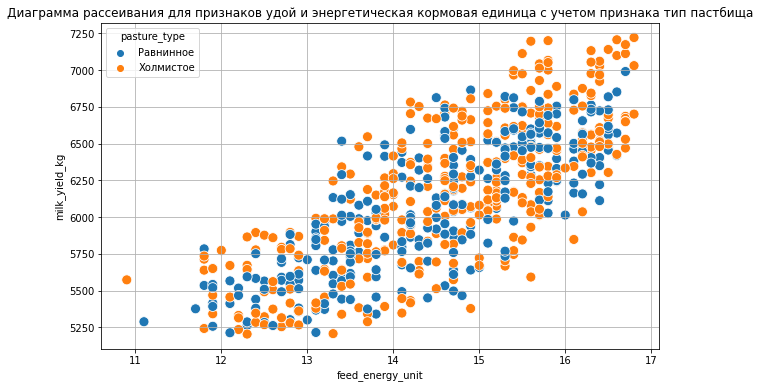

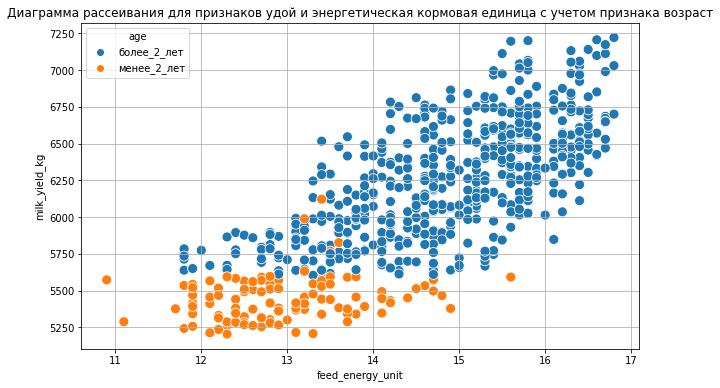

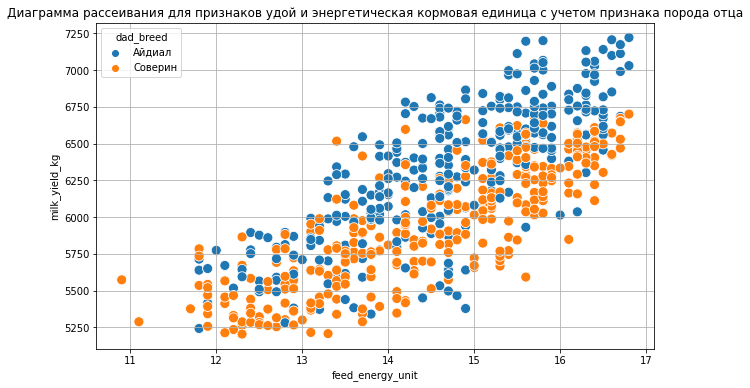

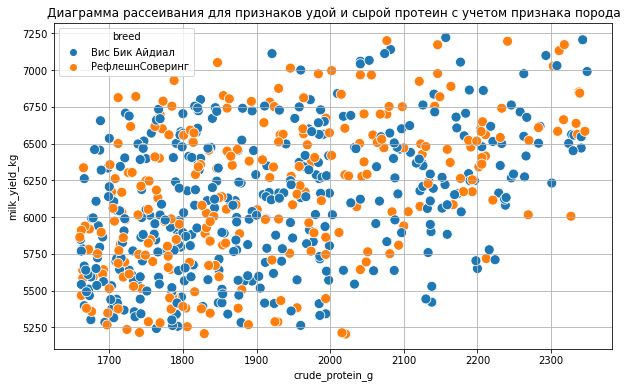

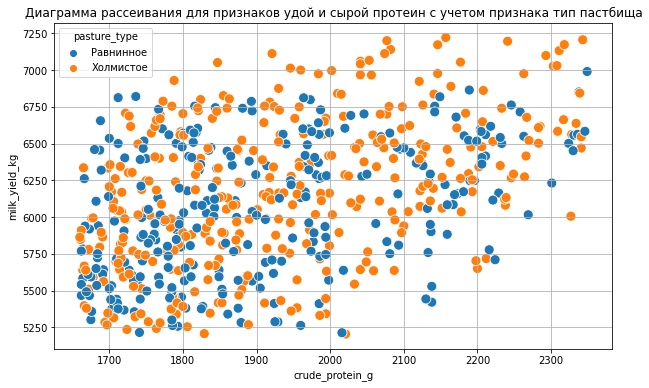

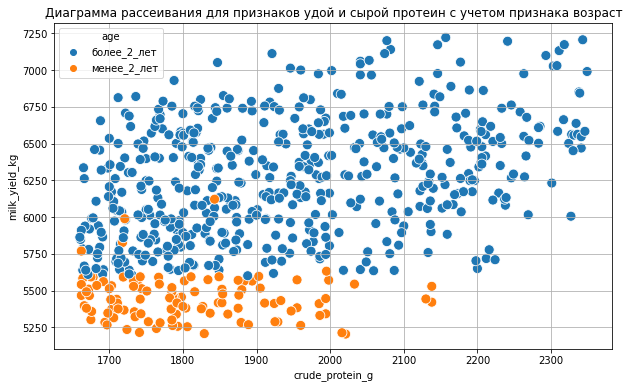

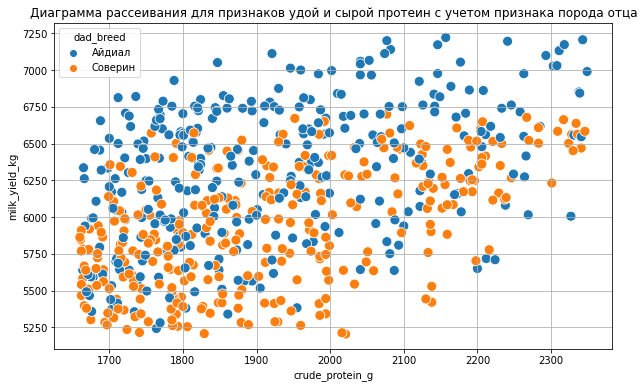

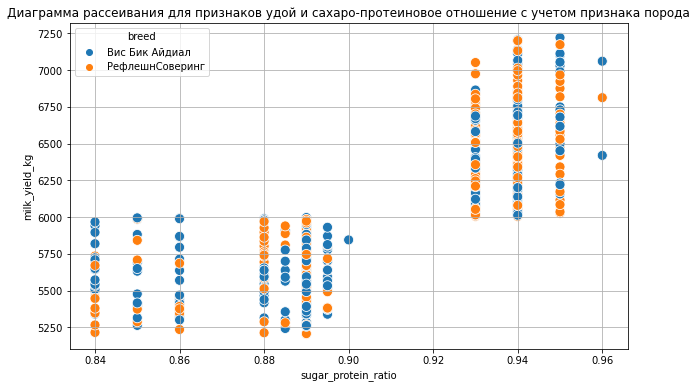

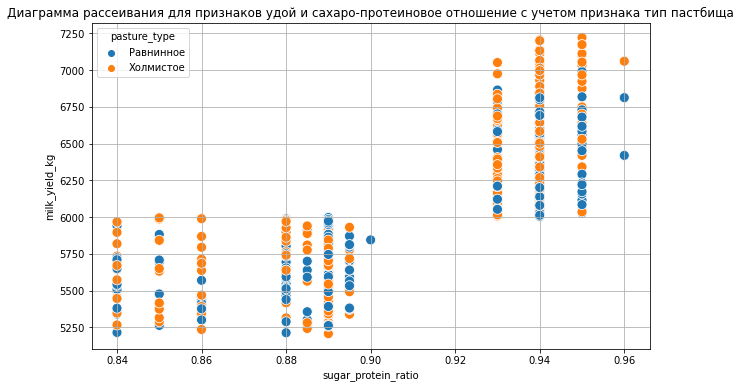

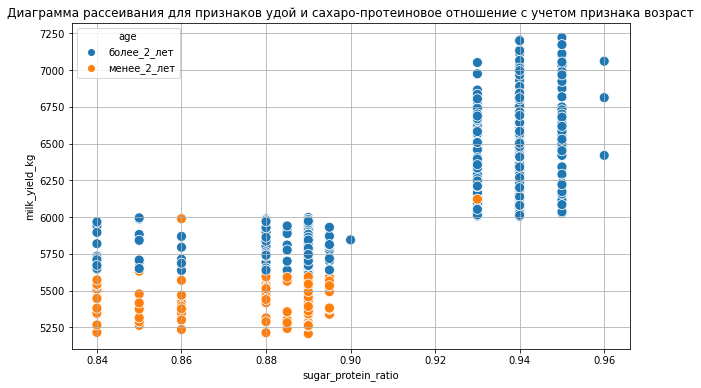

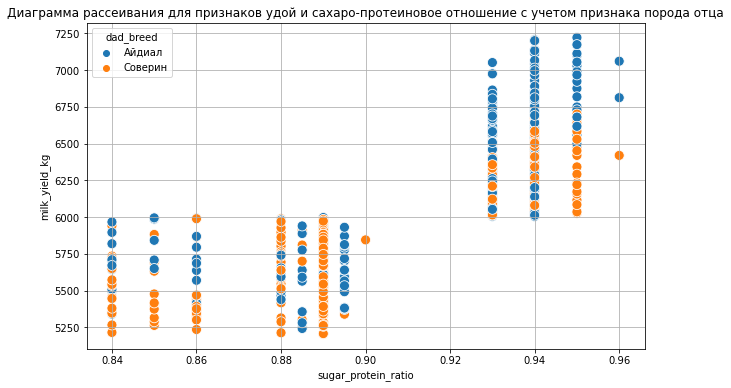

In [64]:
num_columns = ['feed_energy_unit','crude_protein_g', 'sugar_protein_ratio']
# создаем список с названиями количественных признаков
cat_columns = ['breed', 'pasture_type', 'age', 'dad_breed']
# создаем список с названиями качественных признаков
for column1 in num_columns:
    for column2 in cat_columns:
        scatter_plot(column1, column2)
# строим диаграммы рассеивания для всех количественных признаков и удоя с учетом качественных признаков
        

In [65]:
for column1 in num_columns:
    for column2 in cat_columns:
        correlation(column1, column2)
        print(' ')

Порода: Вис Бик Айдиал, корреляция между признаками удой и энергетическая кормовая единица: 0.77
Порода: РефлешнСоверинг, корреляция между признаками удой и энергетическая кормовая единица: 0.76
 
Тип пастбища: Равнинное, корреляция между признаками удой и энергетическая кормовая единица: 0.79
Тип пастбища: Холмистое, корреляция между признаками удой и энергетическая кормовая единица: 0.75
 
Возраст: более_2_лет, корреляция между признаками удой и энергетическая кормовая единица: 0.67
Возраст: менее_2_лет, корреляция между признаками удой и энергетическая кормовая единица: 0.22
 
Порода отца: Айдиал, корреляция между признаками удой и энергетическая кормовая единица: 0.78
Порода отца: Соверин, корреляция между признаками удой и энергетическая кормовая единица: 0.82
 
Порода: Вис Бик Айдиал, корреляция между признаками удой и сырой протеин: 0.42
Порода: РефлешнСоверинг, корреляция между признаками удой и сырой протеин: 0.48
 
Тип пастбища: Равнинное, корреляция между признаками удой и с

In [66]:
ferma_main.query('age == "менее_2_лет"')['milk_yield_kg'].describe()

count     110.000000
mean     5444.245455
std       148.325404
min      5204.000000
25%      5343.000000
50%      5435.500000
75%      5534.500000
max      6122.000000
Name: milk_yield_kg, dtype: float64

### Вывод
Выводы о взаимосвязи признаков 
У взрослых коров (> 2 лет) удой положительно связан:  
- с сырым протеином в корме (r≈0.38–0.48)  
- с жирностью (r≈0.49–0.69)  
- с сахаро-протеиновым отношением (r≈0.74–0.84)  
Причём самая сильная связь — с сахаро-протеиновым отношением, наименьшая — с протеином.
У молодняка (< 2 лет) корреляции близки к нулю или даже отрицательны (rraw protein=–0.09, rratio=0.19, rfat=0.10), то есть для них линейная модель «удой ↔ состав молока» не работает.
Разбивка по породе, типу пастбища мало меняет коэффициенты (разброс ±0.03–0.05), что говорит об устойчивости базовых связей.


Тип взаимосвязи между целевым признаком (удой) и входными (протеин, жирность, сахаро-протеиновое отношение)
- Для взрослых животных взаимосвязи в основном линейно-положительные и монотонные.
- Сильнее всего линейная связь проявляется в отношении «удой ↔ сахаро-протеиновое отношение», меньше всего — «удой ↔ сырой протеин».


Есть ли нелинейные связи? Нужно ли вводить дополнительные признаки?
- Резкое падение корреляций в группе < 2 лет указывает на пороговый эффект по возрасту.
- Нелинейная связь прослеживается между удоем и СПО, несмотря на большой коэффициент корреляции. На диаграмме прослеживаются 2 группы: коровы, СПО корма которых меньше 0.9, и коровы, СПО корма которых больше 0.9. Между удоем и ЭКЕ так же прослеживается нелинейная связь (квадратичная)
- Для взрослых коров явных криволинейных трендов не видно — линейная модель захватывает большую часть зависимости.
- Стоит добавить в таблицу имя отца коровы и посмотреть на динамику ее качества 

Мультиколлинеарность между входными признаками
- Сахаро-протеиновое отношение и энергетическая кормовая единица сильно коррелируют друг с другом
- Категориальные факторы (порода, тип пастбища) явно не коррелируют друг с другом.


<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

## Шаг 5 Обучение модели линейной регрессии

### Первая модель LinearRegression

В качестве входных признаков возьмем все признаки, кроме непосредственно удоя (целевой признак), ЭКЕ (коррелирует с СПО) и количества белка (не коррелирует с удоем совсем)

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Все признаки можно разделить на 3 части:
    
- описывают корову
- описывают содержание коровы
- описывают молоко
        
На удой влияют только первые 2 группы, их и нужно брать. 'feed_energy_unit' удалять не нужно, а вот жирность молока не нужна</s>
</div>

<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Но ведь 'sugar_protein_ratio' и 'feed_energy_unit' сильно коррелируют друг с другом? Не повлияет ли это на качество модели?</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Мультиколлениарными считаются признаки с коэффициентом корреляции выше 0.9, то есть здесь коэффициенты не настолько высокие
</div>

In [67]:
ferma_main.columns

Index(['id', 'milk_yield_kg', 'feed_energy_unit', 'crude_protein_g',
       'sugar_protein_ratio', 'breed', 'pasture_type', 'dad_breed',
       'fat_percent', 'protein_percent', 'milk_taste', 'age'],
      dtype='object')

In [68]:
RANDOM_STATE = 42

In [69]:
X_1 = ferma_main.drop(['id', 'milk_yield_kg', 'fat_percent', 'protein_percent', 'milk_taste'], axis=1)
# создаем датасет с входными признаками
y_1 = ferma_main['milk_yield_kg']
# создаем датасет с целевым признаком

In [70]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, random_state=RANDOM_STATE) 
# делим выборки на тренировочную и тестовую

Создадим функцию, которая подготовит данные для модели: масштабирует количественные данные и кодирует категориальные данные

In [71]:
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse=False)

def transformer(X_train, X_test=None):
    
    # масштабирование количественных данных с помощью StandardScaler
    X_train_scaled = scaler.fit_transform(X_train[num_columns])
    X_test_scaled = scaler.transform(X_test[num_columns])

    # кодирование категориальных данных с помощью OneHotEncoder
    X_train_ohe = encoder.fit_transform(X_train[cat_columns])
    X_test_ohe = encoder.transform(X_test[cat_columns])

    # создадим переменную с новыми названиями столбцов для закодированных данных
    encoder_col_names = encoder.get_feature_names()

    # создаем тренировочный и тестовый датафреймы с закодированными данными
    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

    # создаем тренировочный и тестовый датафреймы с масштабированными данными
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_columns)

    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    # объединяем датафреймы с категориальными и количественными данными
    return X_train, X_test

In [72]:
X_train_1, X_test_1 = transformer(X_train_1, X_test_1)
# подготавливаем тренировочную и тестовую выборки

In [73]:
X_train_1.head()
# проверим данные в тренировочной выборке

,x0_РефлешнСоверинг,x1_Холмистое,x2_менее_2_лет,x3_Соверин,feed_energy_unit,crude_protein_g,sugar_protein_ratio
0,1.0,1.0,0.0,1.0,1.502378,1.079523,0.837130
1,1.0,1.0,1.0,1.0,-1.557270,-0.196920,-0.703660
2,0.0,0.0,0.0,0.0,0.125537,-1.386085,-1.011818
3,0.0,1.0,0.0,0.0,-0.103937,0.752230,0.837130
4,0.0,0.0,0.0,0.0,-1.098323,0.828598,-0.703660


In [74]:
X_test_1.head()
# проверим данные в тестовой выборке

,x0_РефлешнСоверинг,x1_Холмистое,x2_менее_2_лет,x3_Соверин,feed_energy_unit,crude_protein_g,sugar_protein_ratio
0,0.0,1.0,0.0,0.0,-0.486393,-0.813322,-1.011818
1,1.0,1.0,0.0,1.0,1.425887,0.026730,0.837130
2,1.0,1.0,1.0,1.0,-0.486393,-0.682405,-1.628134
3,0.0,0.0,0.0,1.0,-0.945340,-1.058792,-1.011818
4,0.0,1.0,0.0,1.0,0.584484,-1.413360,-0.703660


In [75]:
model_lr_1 = LinearRegression()
# инициализируем модель линейной регрессии

In [76]:
model_lr_1.fit(X_train_1, y_train_1)
# обучаем модель на тренировочной выборке

LinearRegression()

In [77]:
predictions_1 = model_lr_1.predict(X_test_1)
# получаем предсказания

In [78]:
r2_score_1 = r2_score(y_test_1, predictions_1)
# посчитаем коэффициент детерминации

In [79]:
r2_score_1

0.7844078173416966

In [80]:
residuals_1 = y_test_1 - predictions_1
# посчитаем остатки

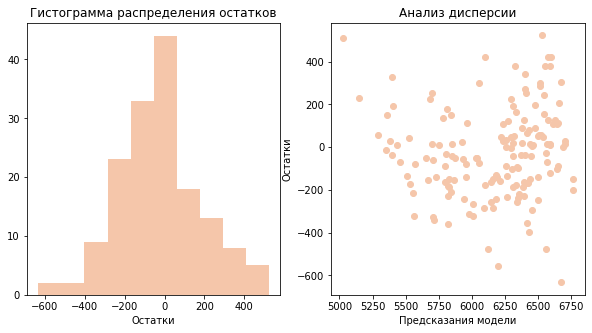

In [81]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals_1, color='#F5C6AA')
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions_1, residuals_1, color='#F5C6AA')
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

#### Вывод
Коэффициент детерминации показывает, что модель верно предсказывает 78% ответов, что является довольно низким показателем точности. На гистограмме остатков видно, что наиболее часто встречаемый "остаток" находится правее 0, это значит, предсказания модели чаще всего меньше реальных значений. Распределение остатков не похоже на нормально и имеет скошенность справа. На диаграмме рассеивания остатков видно, что при предсказаниях более 6250 кг разброс остатков намного больше, чем при других предсказаниях. Это может говорить о том, что в тренировочной выборке не хватает данных о коровах, у которых удой больше 6250 кг в год.

## Вторая модель LinearRegression

Попробуем улучшить модель, устранив нелинейную связь между входными и целевым признаком. Для этого рассмотрим диаграммы рассеивания между удоем и СПО, удоем и ЭКЕ

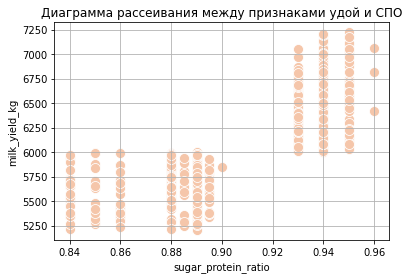

In [82]:
sns.scatterplot(x='sugar_protein_ratio', y='milk_yield_kg', data=ferma_main, color='#F5C6AA', s=100)
plt.title('Диаграмма рассеивания между признаками удой и СПО')
plt.grid(True)
plt.show()

По диаграмме рассеивания между удоем и СПО видно разделение стада на 2 группы: коровы, которые получают корм с СПО меньше 0.9, и коровы, которые получают корм с СПО больше 0.9. Для устранения этой нелинейности преобразуем СПО в категориальный признак бинарный признак: значение 0 получат строки с СПО меньше 0.9, значение 1 получат строки с СПО больше 0.9

In [83]:
ferma_main['sugar_protein_ratio_bin'] = ferma_main['sugar_protein_ratio'] > 0.9
ferma_main['sugar_protein_ratio_bin'] = ferma_main['sugar_protein_ratio_bin'].astype('int')
# преобразуем СПО в бинарный признак

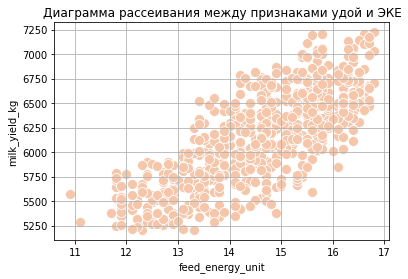

In [84]:
sns.scatterplot(x='feed_energy_unit', y='milk_yield_kg', data=ferma_main, color='#F5C6AA', s=100)
plt.title('Диаграмма рассеивания между признаками удой и ЭКЕ')
plt.grid(True)
plt.show()

Связь между удоем и ЭКЕ напоминает квадратичную, чтобы устранить эту нелинейность добавим признак ЭКЕ в квадрате.

In [85]:
ferma_main['feed_energy_unit_sqr'] = ferma_main['feed_energy_unit']**2

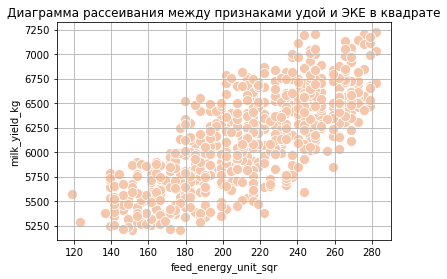

In [86]:
sns.scatterplot(x='feed_energy_unit_sqr', y='milk_yield_kg', data=ferma_main, color='#F5C6AA', s=100)
plt.title('Диаграмма рассеивания между признаками удой и ЭКЕ в квадрате')
plt.grid(True)
plt.show()

In [87]:
RANDOM_STATE = 42

In [88]:
X_2 = ferma_main.drop(['id', 'milk_yield_kg', 'feed_energy_unit', 'protein_percent'], axis=1)
# создаем датасет с входными признаками
y_2 = ferma_main['milk_yield_kg']
# создаем датасет с целевым признаком

In [89]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, random_state=RANDOM_STATE) 
# делим выборки на тренировочную и тестовую

In [90]:
cat_columns.append('sugar_protein_ratio_bin')
num_columns.remove('sugar_protein_ratio')
num_columns.append('feed_energy_unit_sqr')
num_columns.remove('feed_energy_unit')

In [91]:
X_train_2, X_test_2 = transformer(X_train_2, X_test_2)
# подготавливаем тренировочную и тестовую выборки

In [92]:
X_train_2.head()
# проверим данные в тренировочной выборке

,x0_РефлешнСоверинг,x1_Холмистое,x2_менее_2_лет,x3_Соверин,x4_1,crude_protein_g,feed_energy_unit_sqr
0,1.0,1.0,0.0,1.0,1.0,1.079523,1.577968
1,1.0,1.0,1.0,1.0,0.0,-0.196920,-1.511438
2,0.0,0.0,0.0,0.0,0.0,-1.386085,0.082269
3,0.0,1.0,0.0,0.0,1.0,0.752230,-0.150235
4,0.0,0.0,0.0,0.0,0.0,0.828598,-1.102358


In [93]:
X_test_2.head()
# проверим данные в тренировочной выборке

,x0_РефлешнСоверинг,x1_Холмистое,x2_менее_2_лет,x3_Соверин,x4_1,crude_protein_g,feed_energy_unit_sqr
0,0.0,1.0,0.0,0.0,0.0,-0.813322,-0.527089
1,1.0,1.0,0.0,1.0,1.0,0.026730,1.490346
2,1.0,1.0,1.0,1.0,0.0,-0.682405,-0.527089
3,0.0,0.0,0.0,1.0,0.0,-1.058792,-0.961737
4,0.0,1.0,0.0,1.0,0.0,-1.413360,0.561660


In [94]:
model_lr_2 = LinearRegression()
# инициализируем модель линейной регрессии

In [95]:
model_lr_2.fit(X_train_2, y_train_2)
# обучаем модель на тренировочной выборке

LinearRegression()

In [96]:
predictions_2 = model_lr_2.predict(X_test_2)
# получаем предсказания

In [97]:
r2_score_2 = r2_score(y_test_2, predictions_2)
# посчитаем коэффициент детерминации

In [98]:
r2_score_2

0.8180879926867501

In [99]:
residuals_2 = y_test_2 - predictions_2
# посчитаем остатки

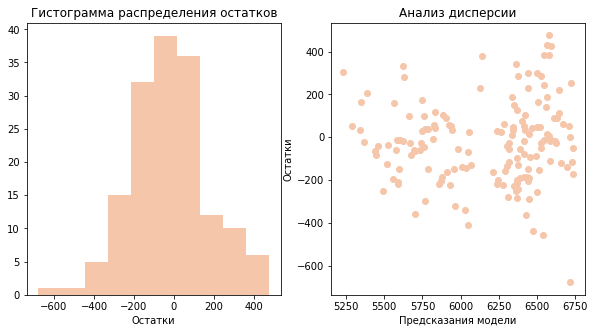

In [100]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals_2, color='#F5C6AA')
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions_2, residuals_2, color='#F5C6AA')
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

#### Вывод
Коэффициент детерминации показывает, что модель верно предсказывает 81% ответов. Наиболее часто встречаемый остаток равен 0, распределение остатков похоже на нормальное, но по-прежнему имеет скошенность справа: модель в меньшую сторону ошибается реже, чем в большую. На диаграмме рассеивания остатков видно, что при предсказаниях более 6250 кг разброс остатков больше, чем при других предсказаниях. Похожая картина наблюдалась для первой модели.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Третья модель LinearRegression

In [101]:
ferma_main = ferma_main.merge(ferma_dad)
# объединим датасеты ferma_main и ferma_dad по индексу методом 'outer', чтобы не потерять ни одну строчку

<div class="alert alert-warning">
<b>🤔 Рекомендация:</b> А для чего нам имена быков, если коров для них не найдется? 'outer' здесь не нужен
</div>

<div class="alert alert-info"> <b>🎓 Верно!</div>

In [102]:
cat_columns.append('dad_name')

In [103]:
X_3 = ferma_main.drop(['id', 'milk_yield_kg', 'feed_energy_unit', 'protein_percent'], axis=1)
# создаем датасет с входными признаками
y_3 = ferma_main['milk_yield_kg']
# создаем датасет с целевым признаком

In [104]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, random_state=RANDOM_STATE) 
# делим выборки на тренировочную и тестовую

In [105]:
X_train_3, X_test_3 = transformer(X_train_3, X_test_3)
# подготавливаем тренировочную и тестовую выборки

In [106]:
X_train_3.head()
# проверим данные в тренировочной выборке

,x0_РефлешнСоверинг,x1_Холмистое,x2_менее_2_лет,x3_Соверин,x4_1,x5_Буйный,x5_Геркулес,x5_Соловчик,crude_protein_g,feed_energy_unit_sqr
0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.079523,1.577968
1,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,-0.196920,-1.511438
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.386085,0.082269
3,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.752230,-0.150235
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.828598,-1.102358


In [107]:
X_train_3.head()
# проверим данные в тестовой выборке

,x0_РефлешнСоверинг,x1_Холмистое,x2_менее_2_лет,x3_Соверин,x4_1,x5_Буйный,x5_Геркулес,x5_Соловчик,crude_protein_g,feed_energy_unit_sqr
0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.079523,1.577968
1,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,-0.196920,-1.511438
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.386085,0.082269
3,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.752230,-0.150235
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.828598,-1.102358


In [108]:
model_lr_3 = LinearRegression()
# инициализируем модель линейной регрессии

In [109]:
model_lr_3.fit(X_train_3, y_train_3)
# обучаем модель на тренировочной выборке

LinearRegression()

In [110]:
predictions_3 = model_lr_3.predict(X_test_3)
# получаем предсказания

In [111]:
r2_score_3 = r2_score(y_test_3, predictions_3)
# посчитаем коэффициент детерминации

In [112]:
r2_score_3

0.8247542745210408

In [113]:
residuals_3 = y_test_3 - predictions_3

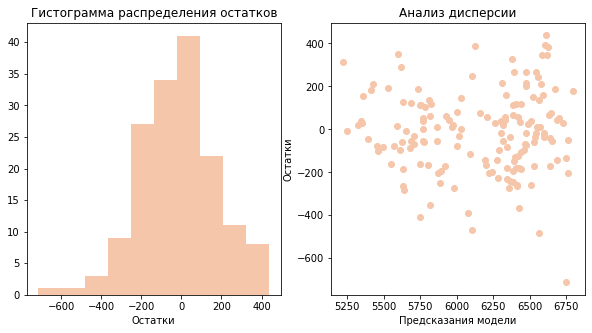

In [114]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals_3, color='#F5C6AA')
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions_3, residuals_3, color='#F5C6AA')
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

#### Вывод
По сравнению с первой моделью коэффициент детерминации вырос на 4% и равен 82%. Распределение остатков похоже на нормальное, все еще сохраняется скошенность справа. На диаграмме рассеивания остатков не прослеживается закономерности, что является хорошим признаком, однако все еще сохраняются ошибки в меньшую сторону для удоя больше 6200 кг. 

<div class="alert alert-danger">
    <s><b>😔 Необходимо исправить:</b> Здесь тоже нужно вывести значение метрики</s>
</div>

<div class="alert alert-info"> <b>🎓 Готово!</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Теперь метрику видно!
</div>

### Выбор лучшей модели

In [115]:
r2_score_data = {
    'Коэффициент детерминации': [r2_score_1, r2_score_2, r2_score_3]
}
index = ['Первая модель', 'Вторая модель', 'Третья модель']
r2_score_data = pd.DataFrame(r2_score_data, index=index)
# создадим таблицу значений R2 для сравнения трех моделей

In [116]:
r2_score_data

,Коэффициент детерминации
Первая модель,0.784408
Вторая модель,0.818088
Третья модель,0.824754


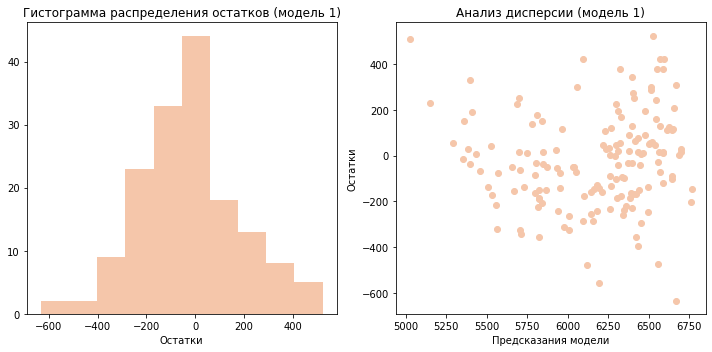

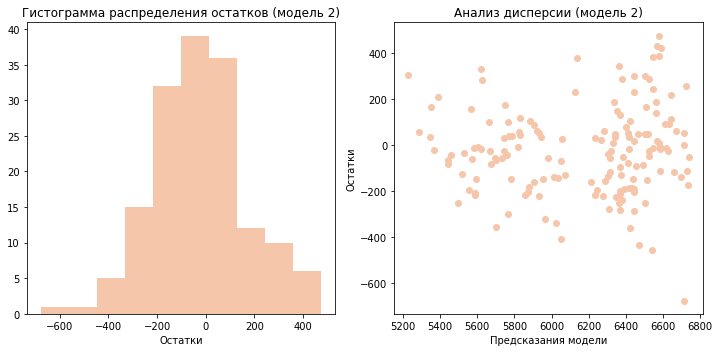

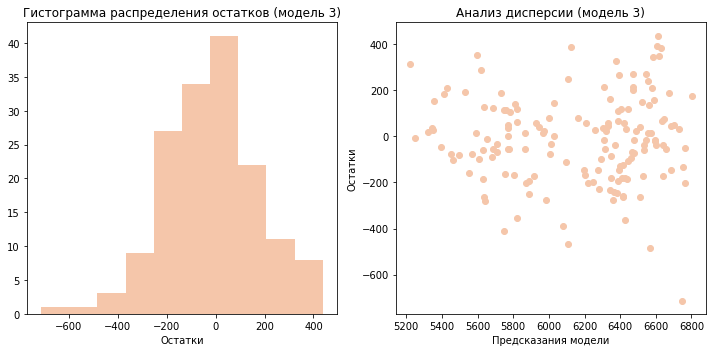

In [117]:
residuals_list = [residuals_1, residuals_2, residuals_3]
predictions_list = [predictions_1, predictions_2, predictions_3]

for i, (res, pred) in enumerate(zip(residuals_list, predictions_list), start=1):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Гистограмма остатков
    axes[0].hist(res, color='#F5C6AA')
    axes[0].set_title(f'Гистограмма распределения остатков (модель {i})')
    axes[0].set_xlabel('Остатки')

    # Диаграмма размаха (residuals vs predictions)
    axes[1].scatter(pred, res, color='#F5C6AA')
    axes[1].set_title(f'Анализ дисперсии (модель {i})')
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')

    plt.tight_layout()
    plt.show()

Лучшая модель из представленных — модель 3:

• R² = 0.82 (максимальное из трёх)  
• Остатки близки к нормальному распределению (гистограмма почти симметрична)  
• На графике «остатки vs предсказания» нет видимой зависимости (гомоскедастичность, минимум выбросов)  

Именно модель 3 обеспечит наименьшую систематическую ошибку прогнозов и более надёжное качество на новых данных.

<div class="alert alert-success">
<b>👍 Успех:</b> Лучшая модель выбрана!
</div>

### Расчет метрик MSE, MAE, RMSE.

In [118]:
def calculate_metrics(y_test, predictions):
    mae = mean_absolute_error(y_test, predictions) # раcчет МАЕ
    mse = mean_squared_error(y_test, predictions) # расчет MSE
    rmse = mean_squared_error(y_test, predictions, squared=False) # расчет RMSE
    return mae, mse, rmse

In [119]:
y_test_list = [y_test_1, y_test_2, y_test_3]

In [120]:
results = [
    calculate_metrics(y_test, pred)
    for y_test, pred in zip(y_test_list, predictions_list)
]
results
# посчитаем метрики для всех моделей

[(164.2419446347493, 43887.01500966053, 209.49227911706086),
 (149.03965222364604, 37030.91131113696, 192.43417396901455),
 (146.16302445362308, 35673.8898861819, 188.8753289505591)]

In [121]:
metric_names = ['mae', 'mse', 'rmse'] # создаем список с названиями метрик
metrics_data = pd.DataFrame(
    results,
    index=['Первая модель', 'Вторая модель', 'Третья модель'],       # временно модели по строкам
    columns=metric_names
)

In [122]:
metrics_data

,mae,mse,rmse
Первая модель,164.241945,43887.015010,209.492279
Вторая модель,149.039652,37030.911311,192.434174
Третья модель,146.163024,35673.889886,188.875329


#### Вывод
Показатели MAE, MSE, RMSE у третьей модели наименьшие, что еще раз подтверждает ее превосходство над остальными моделями

In [123]:
alpha = 0.05
lower_q, upper_q = np.quantile(residuals_3, [alpha/2, 1 - alpha/2])
# рассчитаем доверительный интервал для альфа, равное 5%

In [124]:
lower_q, upper_q

(-393.099637079012, 355.9371511941207)

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Прогноз удоя коров в датасете cow_buy

Прежде чем перейти к прогнозу подготовим данные и дополним недостающие колонки:

In [125]:
columns = ['sugar_protein_ratio', 'crude_protein_g', 'feed_energy_unit']
for column in columns:
    cow_buy[column] = ferma_main[column].mean() * 1.05
# добавим недостающие признаки 

In [126]:
cow_buy['sugar_protein_ratio_bin'] = (cow_buy['sugar_protein_ratio'] > 0.9).astype('int')
# добавляем колонку sugar_protein_ratio_bin

In [127]:
cow_buy['feed_energy_unit_sqr'] = cow_buy['feed_energy_unit'] ** 2
# добавляем колонку feed_energy_unit_sqr

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> На 5% нужно увеличивать изначальное значение СПО и затем преобразовать его в бинарный по той же границе, совершать какие  либо арифиметические опреации с бинарным признаком не нужно. ЭКЕ тоже нужно сначала увеличить на 5%, а затем возвести в квадрат, увеличивать уже возведенный в квадрат признак не нужно, значения будут разные</s>
</div>

<div class="alert alert-info"> <b>🎓 Готово!</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

In [128]:
cow_buy['sugar_protein_ratio_bin']

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
Name: sugar_protein_ratio_bin, dtype: int64

В колонке 'sugar_protein_ratio' все коровы получили значение "1", поэтому при кодировании параметр "drop_first" удалит этот параметр из подготовленной таблицы, в последствии этот столбец нужно будет добавить, чтобы модель работала правильно.

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Данные нужно преобразовывать уже обученными кодировщиком и скайлером, ничего вручную добавлять не нужно и заново обучать тоже не нужно. Обрати внимание, что в некоторых признаках в этом датасете значения совсем другие, не как были в датасете, на котором обучалась модель. Сейчас прогнозы неверные</s>
</div>

<div class="alert alert-info"> <b>🎓 Логично!</div>

In [129]:
cow_buy_scaled = scaler.transform(cow_buy[num_columns])
# масштабируем количественные данные

In [134]:
cow_buy['pasture_type'] = cow_buy['pasture_type'].str.capitalize()

In [136]:
cow_buy_ohe = encoder.transform(cow_buy[cat_columns])
# кодируем качественные данные

In [137]:
encoder_col_names = encoder.get_feature_names()
# получим новые названия

In [138]:
cow_buy_scaled = pd.DataFrame(cow_buy_scaled, columns=num_columns)
cow_buy_ohe = pd.DataFrame(cow_buy_ohe, columns=encoder_col_names)
# создадим 2 датафрейма с масштабированными и кодированными данными

In [139]:
cow_buy_transformed = pd.concat([cow_buy_ohe, cow_buy_scaled], axis=1)
# объединим 2 датафрейма

In [140]:
cow_buy_transformed.head()

,x0_РефлешнСоверинг,x1_Холмистое,x2_менее_2_лет,x3_Соверин,x4_1,x5_Буйный,x5_Геркулес,x5_Соловчик,crude_protein_g,feed_energy_unit_sqr
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.517384,0.542248
1,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.517384,0.542248
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.517384,0.542248
3,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.517384,0.542248
4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.517384,0.542248


In [141]:
milk_yield_predictions = model_lr_3.predict(cow_buy_transformed)
# спрогнозируем удой коров для покупки

In [142]:
milk_yield_predictions

array([6609.91929681, 6378.71102836, 6283.99977532, 6593.08937654,
       6542.14606633, 6425.38021759, 6609.91929681, 6571.25973712,
       6283.99977532, 6400.54066779, 6344.70785976, 6617.92892634,
       6609.91929681, 6127.4747423 , 6283.99977532, 6593.08937654,
       6344.70785976, 6425.38021759, 6571.25973712, 6542.14606633])

### Вывод
В ходе подбора модели линейной регрессии мы обучили 3 модели, наиболее точной из которых оказалась третья модель, которая учитывалая ЭКЕ в квадрате и имя папы быка. С помощью этой модели мы предсказали удой для коров, рассматриваемых для покупки, только 2 из них не соответствуют требованиям (без учета доверительного интервала).

<div class="alert alert-success">
<b>👍 Успех:</b> Отлично! Все коровы будут давать нужное количество молока!
</div>

## Шаг 6 Обучение модели логистической регрессии

<div class="alert alert-warning">
<b>🤔 Рекомендация:</b> Нет смысла смотреть нелинейную корреляцию для линейной модели
</div>

<div class="alert alert-info"> <b>🎓 👌</div>

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Здесь нужно брать больше признаков, и обязательно должны быть все признаки, описывающие молоко</s>
</div>

<div class="alert alert-info"> <b>🎓 Честно говоря, не совсем понятно, по какому принципу здесь выбрать признаки. Можно ли выбрать удой в качестве входного признака, учитывая, что мы его будет предсказывать?</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Да, можно использовать спрогнозированные значения (но не обязательно)
</div>

In [212]:
# создаем датафрейм с входными и целевым признаками
X_log = ferma_main[[
    'feed_energy_unit', 
    'crude_protein_g',
    'sugar_protein_ratio_bin',
    'breed', 
    'pasture_type', 
    'dad_name', 
    'dad_breed',
    'fat_percent',
    'protein_percent',
    'age'
]]

y_log = (ferma_main['milk_taste'] == 'вкусно').astype('int')

In [213]:
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(X_log, y_log, random_state=RANDOM_STATE)
# делим данные на выборки

In [215]:
cat_columns = [
    'sugar_protein_ratio_bin',
    'breed',
    'pasture_type',
    'dad_name',
    'dad_breed',
    'age'    
]
# удаляем лишние наименования из cat_columns

In [216]:
num_columns = [
    'feed_energy_unit',
    'crude_protein_g', 
    'fat_percent',
    'protein_percent'
    ]
# перепишем список num_columns с актуальными колонками

In [217]:
X_log_train, X_log_test = transformer(X_log_train, X_log_test)
# трансформируем данные

In [218]:
clf = LogisticRegression()

In [219]:
clf = clf.fit(X_log_train, y_log_train)

In [220]:
y_pred = clf.predict(X_log_test)

In [221]:
accuracy_score(y_log_test, y_pred)
# посчитаем метрику accuracy

0.6305732484076433

In [222]:
precision_score(y_log_test, y_pred)
# посчитаем метрику precision

0.6229508196721312

In [223]:
recall_score(y_log_test, y_pred)
# посчитаем метрику recall

0.8636363636363636

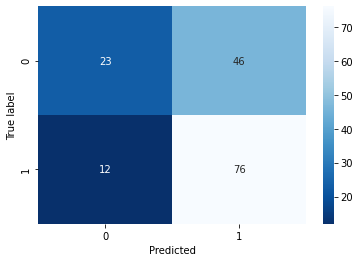

In [224]:
cm = confusion_matrix(y_log_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted')
plt.show()
# построим матрицу ошибок

Значения accuracy и precision получились равными 63% и 62%, что достаточно мало, однако значение recall получилось равным 85%. Это означает, что модель совершает очень много ошибок первого рода, то есть ложноположительных предсказаний, что в нашем случае является наиболее критичной ошибкой, так как первостепенная цель у фермера получить вкусное молоко. Для того, чтобы фермер не купил корову с невкусным молоком необходимо минимизировать ошибку первого рода, то есть увеличивать precision. Для этого необходимо увеличивать порог классификации. 

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно! Максимизировать будем precision
</div>

In [225]:
y_proba = clf.predict_proba(X_log_test)[:,1]

data = pd.DataFrame(zip(y_log_test, y_proba),
             columns = ['y_valid', 'y_proba']).sort_values(by='y_proba',ascending=False)
# создадим датафрем с настоящим значением и получившейся вероятностью

In [226]:
data.head()

,y_valid,y_proba
85,1,0.855926
51,1,0.842432
66,1,0.839103
110,1,0.835965
147,1,0.812657


In [227]:
thresholds = [round(i,2) for i in np.linspace(0.5,1,num = 100,endpoint=False)]
# создадим новые пороги от 0.5 до 1

In [228]:
# создаём переменную, которая будет хранить список новых колонок
columns = []

# добавляем столбцы с новыми предсказаниями
for i in thresholds:
	columns.append('y_pred_'+str(i))
	data['y_pred_'+str(i)] = data['y_proba'].apply(lambda x: 1 if x >= i else 0 )

In [229]:
data.head(10)

,y_valid,y_proba,y_pred_0.5,y_pred_0.51,y_pred_0.52,y_pred_0.53,y_pred_0.54,y_pred_0.55,y_pred_0.56,y_pred_0.57,...,y_pred_0.91,y_pred_0.92,y_pred_0.93,y_pred_0.94,y_pred_0.95,y_pred_0.96,y_pred_0.97,y_pred_0.98,y_pred_0.99,y_pred_1.0
85,1,0.855926,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
51,1,0.842432,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
66,1,0.839103,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
110,1,0.835965,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
147,1,0.812657,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
8,1,0.806141,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
136,1,0.802636,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
108,0,0.798082,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
114,1,0.792998,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0.791135,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


Посчитаем precision для каждого y_pred

In [230]:
pred_cols = data.loc[:, data.columns.str.startswith("y_pred_")] 
# выбираем все колонки, начинающиеся на "y_pred"

prec = pred_cols.apply(lambda col: precision_score(data["y_valid"], col, zero_division=0))
# применим к колонкам функцию precision

rec = pred_cols.apply(lambda col: recall_score(data["y_valid"], col, zero_division=0))

result = pd.concat([prec, rec], axis=1)
result.columns = ['precision', 'recall']

In [231]:
result[result['precision'] >= 0.9]

,precision,recall
y_pred_0.79,0.909091,0.113636
y_pred_0.8,1.000000,0.079545
y_pred_0.81,1.000000,0.056818
y_pred_0.82,1.000000,0.045455
y_pred_0.83,1.000000,0.045455
y_pred_0.84,1.000000,0.022727
y_pred_0.85,1.000000,0.011364


Чтобы минимизировать риск получить невкусное молоко, будет стремиться к значению precison, равному 1, однако чтобы значение recall не стремилось к 0, рассмотрим значения больше или равноые 0.9.  При значении порога 0.79 значение precision достигает 90%, при этом значение recall равняется 0.11, что не так мало, как значения recall для бОльших значений precision. Поэтому оптимальнее всего будет выбрать именно этот порог 

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Почему 0.8? Стремиться нужно к 1, можно немного снизить, например до 0.9-0.95. И шаг нужно сделать меньше, 20 значений порога очень мало</s>
</div>

<div class="alert alert-info"> <b>🎓 Согласна, что нужно стремиться к 1, но ведь и значение recall, близкое к - малоэффективно? По сути с такой моделью фермер не сможет купть ни одной коровы (как видно ниже)</div>

<div class="alert alert-success">
<b>👍 Успех:</b> Да, здесь получается, что мы не можем гарантировать вкусное молоко. Стоит добавить столбец с вероятностью вусного молока и фермер сможет принять решение насколько он хочет рискнуть и даст ему основание попросить скидку на некоторых коров
</div>

In [245]:
threshold = 0.79

In [246]:
y_pred_custom = (y_proba >= threshold).astype(int)

In [247]:
accuracy_score(y_log_test, y_pred_custom)

0.4968152866242038

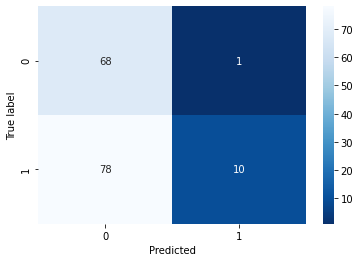

In [248]:
cm = confusion_matrix(y_log_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted')
plt.show()
# построим матрицу ошибок

### Вывод
Фермеру важно получить вкусное молоко, убыток от покупки и содержания коровы, которая дает невкусное молоко будет меньше, чем потеря прибыли от коровы, которая дала бы вкусное молоко, но не была выбрана для покупки. В таком случае лучше ориентироваться на precision и стараться его максимизировать, чтобы уменьшить ошибку 1 рода, однако забывать про recall тоже не стоит и устремлять его в 0, так как увеличить стадо с помощью качественных коров фермер все же хочет. Наиболее оптимальным значением порога для необходимого precision и ненулевого recall стало значение 0.79, accuracy для которого равно 0.49. Такое небольшое значение accuracy можно объяснить субъективностью мнения фермера, так как все же нет четких требований и закономерности "вкусного" молока.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Прогноз вкуса молока в датафрейме cow_buy

In [249]:
num_columns[num_columns.index('fat_percent')] = 'current_fat_percent'
num_columns[num_columns.index('protein_percent')] = 'current_protein_percent'

ValueError: 'fat_percent' is not in list

In [250]:
cow_buy_scaled = scaler.transform(cow_buy[num_columns])
# масштабируем количественные данные

<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Здесь тоже нельзя заново ничего обучать, у тебя уже есть обученные кодировщик и скайлер</s>
</div>

<div class="alert alert-info"> <b>🎓 Да</div>

In [251]:
cow_buy_ohe = encoder.transform(cow_buy[cat_columns])
# кодируем качественные данные

In [252]:
encoder_col_names = encoder.get_feature_names()
# получим новые названия

In [253]:
cow_buy_scaled = pd.DataFrame(cow_buy_scaled, columns=num_columns)
cow_buy_ohe = pd.DataFrame(cow_buy_ohe, columns=encoder_col_names)
# создадим 2 датафрейма с масштабированными и кодированными данными

In [254]:
cow_buy_transformed = pd.concat([cow_buy_ohe, cow_buy_scaled], axis=1)
# объединим 2 датафрейма

In [255]:
probabilities = clf.predict_proba(cow_buy_transformed)

In [256]:
milk_taste_predictions = (probabilities >= threshold).astype(int)

In [257]:
milk_taste_predictions[:, 1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Вывод
В ходе обучения модели логистической регрессии мы я выявила наиболее критичную ошибку - ошибку 1 рода и при создании модели классификации учитывала этот факт. Чтобы уменьшить ошибку 1 рода, необходимо увеличивать precision, что я и делала при подборе порога классификации. Наилучшим, на мой взгляд, порого стал порог в 0.79, так как при нем уровень precision достиг 90%, а уровень recall не уменьшился в 0. По результатам прогноза ни одна корова из всех представленных не будет иметь вкусное молоко.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

# Шаг 7 Итоговые выводы

In [258]:
cow_buy['milk_yield_predictions'] = milk_yield_predictions
cow_buy['milk_yield_predictions_lower_q'] = milk_yield_predictions + lower_q
cow_buy['milk_yield_predictions_upper_q'] = milk_yield_predictions + upper_q
# добавим в датафрейм cow_buy предсказания удоя с левой и правой границей доверительного промежутка

In [259]:
cow_buy['milk_taste_predictions'] = milk_taste_predictions[:, 1]

In [260]:
cow_buy

,breed,pasture_type,dad_breed,dad_name,current_fat_percent,current_protein_percent,age,sugar_protein_ratio,crude_protein_g,feed_energy_unit,sugar_protein_ratio_bin,feed_energy_unit_sqr,milk_yield_predictions,milk_yield_predictions_lower_q,milk_yield_predictions_upper_q,milk_taste_predictions
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6609.919297,6216.819660,6965.856448,0
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6378.711028,5985.611391,6734.648180,0
2,РефлешнСоверинг,Равнинное,Соверин,Барин,3.59,3.074,более_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6283.999775,5890.900138,6639.936927,0
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6593.089377,6199.989739,6949.026528,0
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6542.146066,6149.046429,6898.083218,0
5,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6425.380218,6032.280581,6781.317369,0
6,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6609.919297,6216.819660,6965.856448,0
7,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6571.259737,6178.160100,6927.196888,0
8,РефлешнСоверинг,Равнинное,Соверин,Барин,3.59,3.074,более_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6283.999775,5890.900138,6639.936927,0
9,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,0.958744,2019.947532,15.276162,1,233.361138,6400.540668,6007.441031,6756.477819,0


In [261]:
cow_buy.query('milk_yield_predictions > 6000 and milk_taste_predictions == 1')['breed'].count()
# посчитаем количество коров купленных коров с минимальными рисками

0

### Вывод
1. С минимальными рисками фермер не сможет купить ни одной коровы, так как ни одна из представленных коров не будет иметь

2. Фермеру стоит посчитать убыток от покупки коровы, не удовлетворяющей критериям, и отказа от покупки коровы, которая потенциально могла принести прибыль. И уже с учетом этих сумм посчитать риски и скорректировать значения метрик и порога классификации.

3. В задаче линейной регрессии для улучшения качества модели я работала с нелинейной связью между признаками: возводила в квадрат ЭКЕ и рассмотрела СПО в качестве бинарного признака, а так же добавила новый признак - имя отца, исключила мультиколлинеарность. Все это позволило улучшить качество модели на 11%. В контексте нашей задачи, используя навыки, приобретенные в текущем спринте улучшить модель линейной регрессии еще больше, мне не представляется возможным, возможно использование новых навыков или других видов моделей позволить предсказывать удой лучше.

4. При анализе рисков и экономических расчетов необходимо обращать внимание на метрики recall и precision и в зависимости от задачи действовать на увеличение одной из них. В нашей задаче критичной ошибкой была ошибка 1 рода - фермеру важно получить вкусное молоко, поэтому мы сосредоточились на увеличении метрики precision, так как купить корову с невкусным молоком в нашей задаче более критично, чем пропустить корову с вкусным молоком. 

 <div class="alert alert-success">
 <b>👍 Успех:</b> Хороший проект. Молодец! Изучены все параметры, построено несколько моделей и оценено их качество.

 - тебе удалось добиться очень хорошего качества, поздравляю!

Могу посоветовать посмотреть видеоразбор <a href="https://rutube.ru/video/388292df106f49910b3891d3a753b217/">Как обучить модель по шагам в Data Science? Урок для начинающих на примере задачи регрессии</a>

 - Рекомендую тебе ознакомиться со статьями по интерпретации предсказания моделей:  <a href="https://habr.com/ru/post/428213/">SHAP</a>,   <a href="https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137">+ еще ссылка</a>.

 В этом проекте все шаги отработаны и цель проекта достигнута. Рада была тебе помочь)

 </div>